In [3]:
!pip install plotly



In [4]:
!pip install seaborn

In [5]:
!pip install nbformat>=4.2.0

zsh:1: 4.2.0 not found


In [6]:
import pandas as pd
import plotly.express as px
import nbformat
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data/rice_classification.csv")

In [8]:
df

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [10]:
df.dropna()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


In [11]:
df.isna().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64

In [12]:
df.shape

(3810, 8)

In [13]:
df['Major_Axis_Length'].max()


np.float64(239.010498046875)

In [14]:
df['Major_Axis_Length'].min()

np.float64(145.264465332031)

In [15]:
df['Perimeter'].std()

np.float64(35.59708144273355)

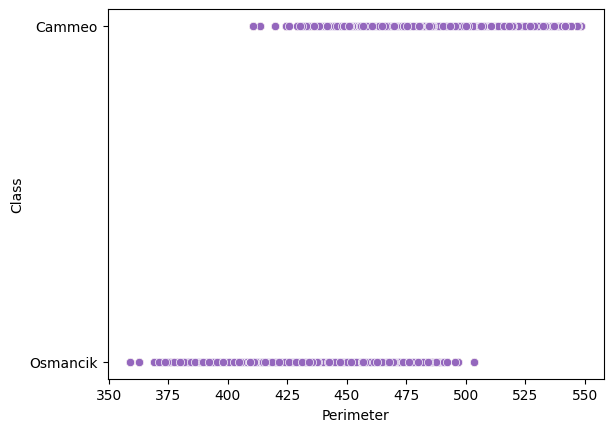

In [16]:
for x_axis_data, y_axis_data in[
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter','Extent'),
    ('Eccentricity', 'Major_Axis_length'),
]:
   #px.scatter(df, x=x_axis_data, y=y_axis_data, color='Class').show()
   #plt.scatter(df['Area'], df['Perimeter'])
   sns.scatterplot(data=df, x='Perimeter', y= 'Class')

In [17]:
px.scatter_3d(
    df,
    x='Eccentricity',
    y='Area',
    z='Major_Axis_Length',
    color='Class',
).show()

TypeError: no numeric data to plot

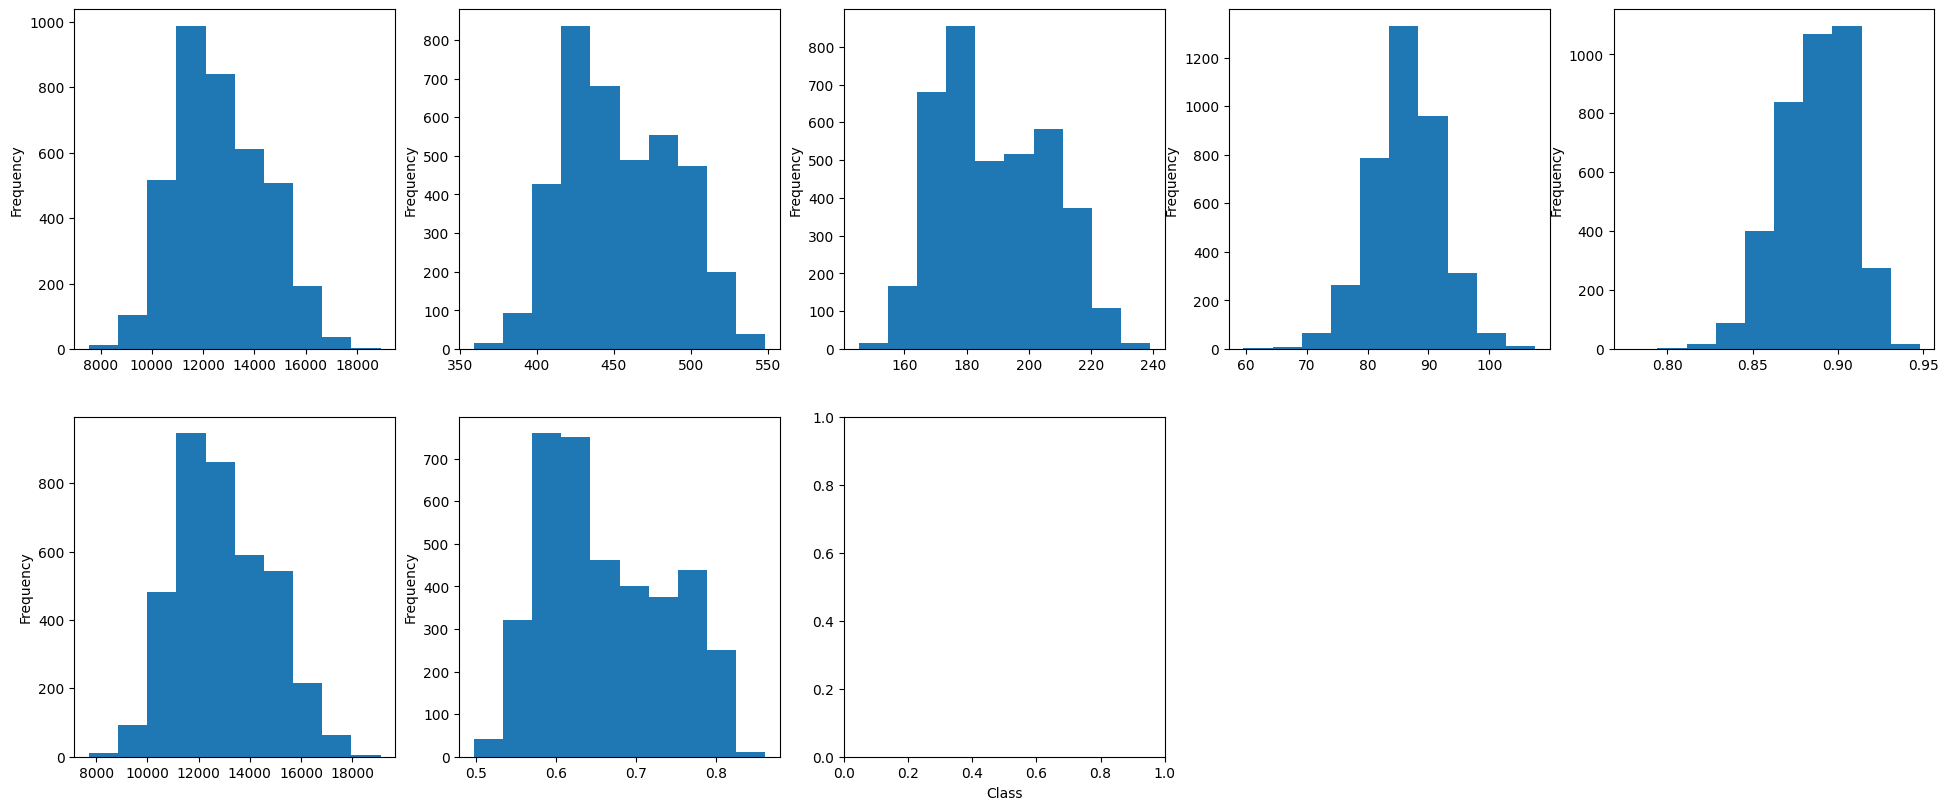

In [18]:
fig = plt.figure(figsize=(24,15))
i =0
for column in df:
    sub = fig.add_subplot(3,5,i+1)
    sub.set_xlabel(column)
    df[column].plot(kind = 'hist')
    
    i = i+1       
fig.tight_layout()
plt.show()             

In [19]:
Categories = ["Area","Perimeter", 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity','Convex_Area']

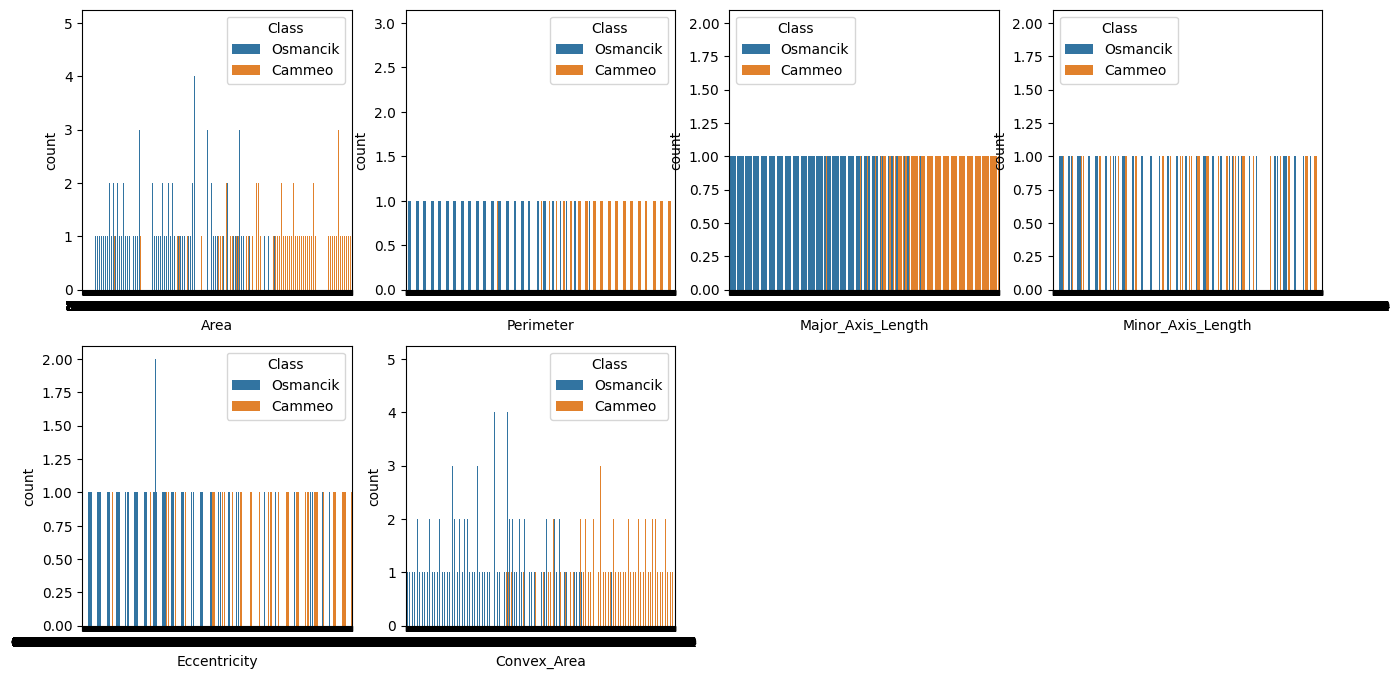

In [20]:
fig =plt.figure(figsize=(16,8))
for i in range(len(Categories)):
    column = Categories[i]
    sub = fig.add_subplot(2,4, i+1)
    chart = sns.countplot(data= df, x= column, hue='Class' )

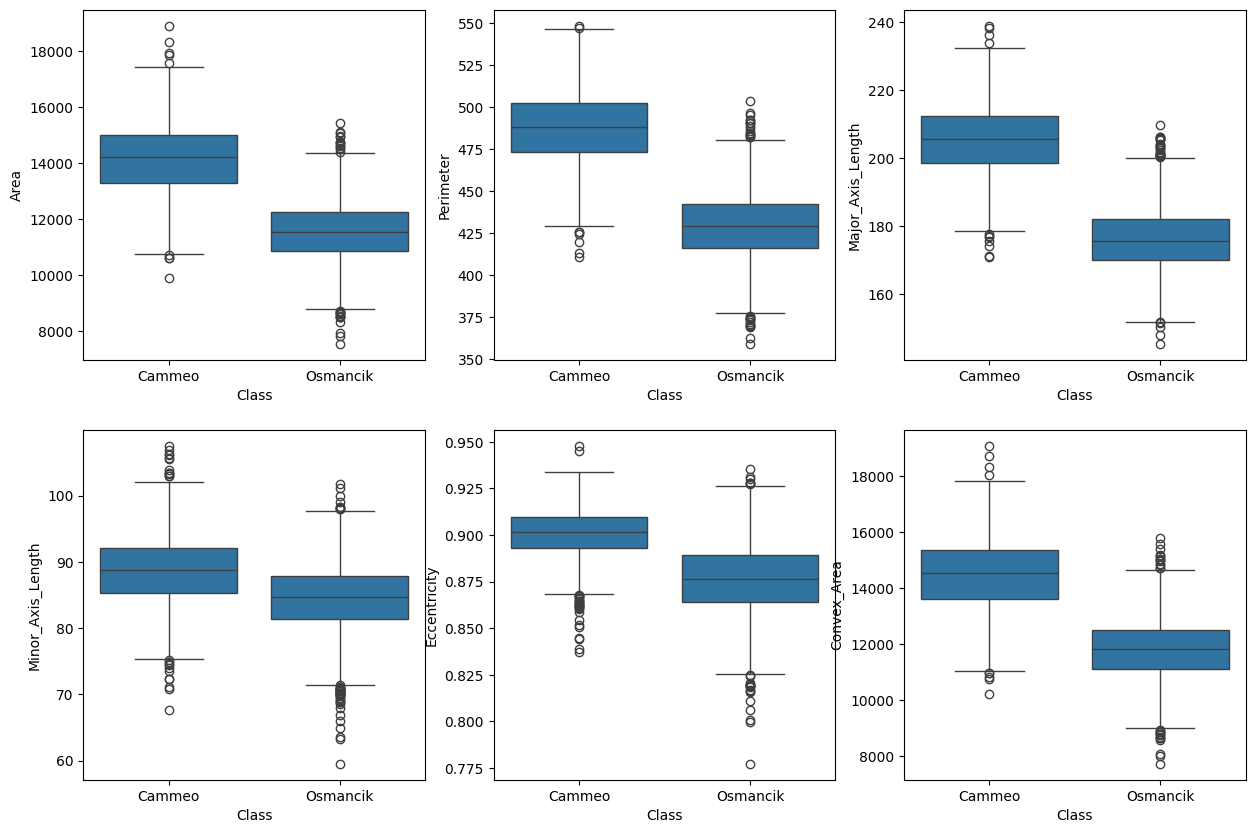

In [21]:
fig = plt.figure(figsize=(15,10))
for i in range(len(Categories)):
    column=Categories[i]
    sub = fig.add_subplot(2,3,i+1)
    sns.boxplot(x='Class', y = column,data=df)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


In [24]:
df.shape

(3810, 8)

In [25]:
target = df['Class']


In [ ]:
target

In [26]:
df = df.drop('Class', axis = 1)
 

In [ ]:
df

In [27]:
df_train, df_test, target_train, target_test = train_test_split(df, target,test_size = 0.2, random_state = 42, stratify=target)

In [28]:
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train)
df_test_scaled = scaler.fit_transform(df_test)

In [31]:
knn =KNeighborsClassifier(n_neighbors=3)
knn.fit(df_train_scaled, target_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
predictions = knn.predict(df_test_scaled)

In [33]:
accuracy = accuracy_score (target_test, predictions)

In [34]:
print(f"Accuracy: {accuracy * 100 :.2f}%")

Accuracy: 89.76%


In [35]:
print(f"Acutal class : {target_test}")


Acutal class : 1         Cammeo
3396    Osmancik
2755    Osmancik
1990    Osmancik
627       Cammeo
          ...   
1446      Cammeo
2772    Osmancik
805       Cammeo
775       Cammeo
2123    Osmancik
Name: Class, Length: 762, dtype: object


In [36]:
print(f"Predicted Class : {predictions}")

Predicted Class : ['Cammeo' 'Cammeo' 'Osmancik' 'Osmancik' 'Cammeo' 'Osmancik' 'Cammeo'
 'Cammeo' 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik'
 'Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Cammeo' 'Osmancik' 'Osmancik'
 'Osmancik' 'Cammeo' 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik' 'Cammeo'
 'Cammeo' 'Osmancik' 'Cammeo' 'Cammeo' 'Osmancik' 'Cammeo' 'Osmancik'
 'Osmancik' 'Osmancik' 'Cammeo' 'Cammeo' 'Cammeo' 'Osmancik' 'Cammeo'
 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik' 'Cammeo'
 'Osmancik' 'Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Cammeo' 'Osmancik'
 'Cammeo' 'Osmancik' 'Cammeo' 'Osmancik' 'Cammeo' 'Cammeo' 'Cammeo'
 'Osmancik' 'Cammeo' 'Cammeo' 'Cammeo' 'Osmancik' 'Osmancik' 'Cammeo'
 'Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Osmancik' 'Cammeo' 'Osmancik'
 'Cammeo' 'Osmancik' 'Cammeo' 'Cammeo' 'Cammeo' 'Osmancik' 'Cammeo'
 'Cammeo' 'Cammeo' 'Osmancik' 'Cammeo' 'Cammeo' 'Osmancik' 'Osmancik'
 'Cammeo' 'Cammeo' 'Cammeo' 'Cammeo' 'Osmancik' 'Cammeo' 'Cammeo' 'Cam